In [1]:
import numpy as np
import random as rn
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow
import os, json

# Custom Settings
from convex_map import generate_map
from heatmap_animation import generate_heatmap
from map_visualization import _bounce_angle, animate_camera_rotation, visualize_map_at_time
from json_seriablizable import make_json_serializable
from stp_rrtstar import run_and_save, stp_rrtstar, PlannerConfig

In [2]:
# World Param
map_size = (50, 50)
num_buildings = 2
num_sensors = 3
fov_half_rad = np.deg2rad(15)
max_range = 20
panspeed_range = (np.deg2rad(-10), np.deg2rad(10))
cam_period = 200
cam_increment = 0.2
rng_seed = 2

(<Figure size 600x600 with 1 Axes>,
 <AxesSubplot:title={'center':'Operation Map @ t = 0.00'}>)

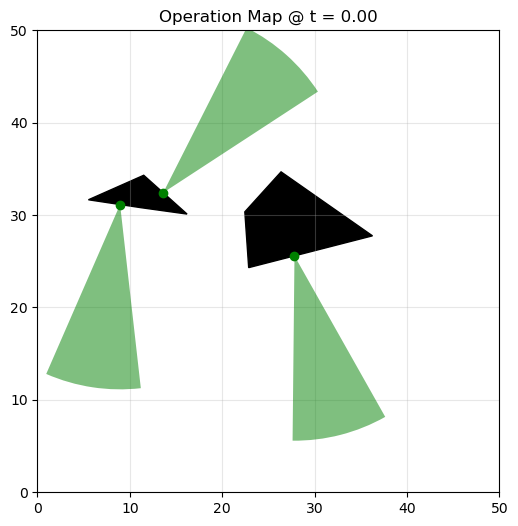

In [3]:
# Run to Generate Map for Operation
map_in, cam_dict = generate_map(
    map_size = map_size,
    num_buildings = num_buildings,
    num_sensors = num_sensors,
    fov_half_rad = fov_half_rad,
    max_range = max_range,
    panspeed_range = panspeed_range,
    cam_period = cam_period,
    cam_increment = cam_increment,
    rng_seed = rng_seed,
    balanced_sensors = False     # spread sensors across buildings
)

visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5)

In [4]:
# Setup for STP-RRT*
x0 = [0, 0, 0]
xf = [50, 50, 60]
vmax = 5

stp_rrt_setup = {}
stp_rrt_setup['x0'] = x0
stp_rrt_setup['xf'] = xf
stp_rrt_setup['vmax'] = vmax

# Output into JSON file
# Full path to the file
file_path1 = os.path.join("json/zero_sum_game", "operation_map.json")
file_path2 = os.path.join("json/zero_sum_game", "defender_info.json")
file_path3 = os.path.join("json/zero_sum_game", "stp_rrt_setup.json")

# Write JSON file into that folder
with open(file_path1, "w") as f:
    json.dump(make_json_serializable(map_in), f, indent=4)

with open(file_path2, "w") as f:
    json.dump(make_json_serializable(cam_dict), f, indent=4)

with open(file_path3, "w") as f:
    json.dump(stp_rrt_setup, f, indent=4)

In [5]:
# import numpy as np
# from shapely.geometry import Point, Polygon

# # Generate dmap
# class RotatingEOandAcoustic:
#     def __init__(self):
#         self.eo_center = (7.0, 3.0); self.eo_R = 6.0
#         self.eo_half  = np.deg2rad(45.0)   # half-angle
#         self.eo_rate  = 0.5                # rad/s
#         self.ac_center = (3.0, 7.0); self.ac_R = 3.0

#     def _sector(self, cx, cy, R, yaw, half, n=48):
#         ang = np.linspace(-half, half, n) + yaw
#         pts = [(cx, cy)] + [(cx + R*np.cos(a), cy + R*np.sin(a)) for a in ang] + [(cx, cy)]
#         return Polygon(pts)

#     def gen_cam(self, i, t):
#         if i == 0:  # EO/IR rotating sector
#             yaw = self.eo_rate * float(t)
#             return self._sector(*self.eo_center, self.eo_R, yaw, self.eo_half)
#         if i == 1:  # acoustic disk
#             return Point(*self.ac_center).buffer(self.ac_R, resolution=64)
#         return None

# dmap = RotatingEOandAcoustic()


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41
Iteration: 42
Iteration: 43
Iteration: 44
Iteration: 45
Iteration: 46
Iteration: 47
Iteration: 48
Iteration: 49
Iteration: 50
Iteration: 51
Iteration: 52
Iteration: 53
Iteration: 54
Iteration: 55
Iteration: 56
Iteration: 57
Iteration: 58
Iteration: 59
Iteration: 60
Iteration: 61
Iteration: 62
Iteration: 63
Iteration: 64
Iteration: 65
Iteration: 66
Iteration: 67
Iteration: 68
Iteration: 69
Iteration: 70
Iteration: 71
It

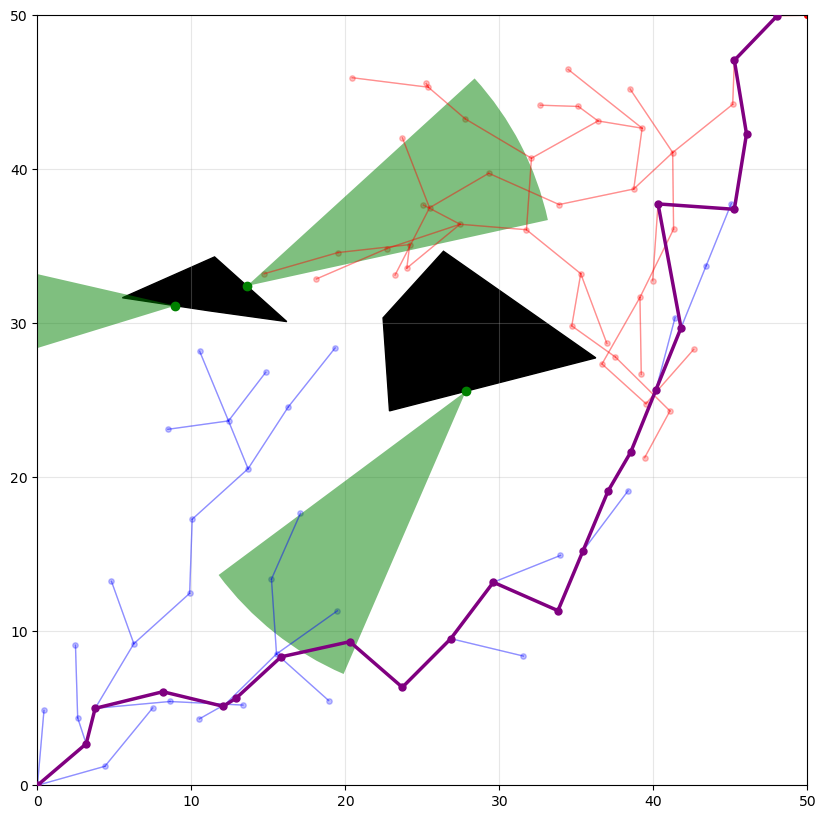

/tmp/ipykernel_8944/2392673736.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return (float(xq), float(yq)) if np.ndim(t_query) == 0 else (xq, yq)
/tmp/ipykernel_8944/2392673736.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return (float(xq), float(yq)) if np.ndim(t_query) == 0 else (xq, yq)


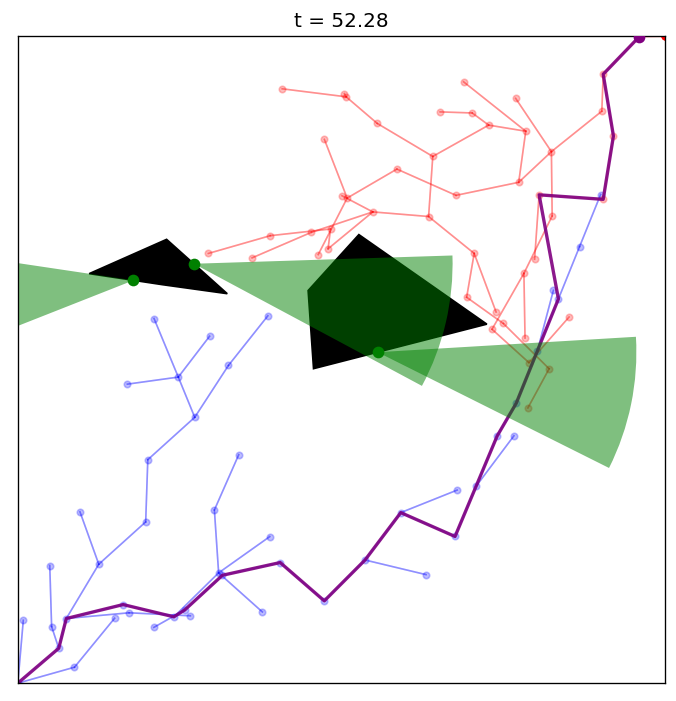

In [6]:
# Run STP-RRT* Notebook:
%run ./stp_rrtstar.ipynb
file_path_stp_rrtstar = os.path.join("json/zero_sum_game", "stp_rrt_result.json")
# cfg = PlannerConfig(
#     map_size=map_size,  # world bounds
#     v_max=vmax,              # m/s
#     steer_step=5,         # m (spatial step per extension)
#     t_step_min=0.1,         # s
#     t_step_max=1.0,         # s
#     vehicle_radius=0.1,     # m
#     goal_radius=1,        # m
#     rewire_radius=0.5,      # m (kept small; rewiring is limited by causality)
#     max_iter=20000,         # safety cap
#     comp_time_limit=180,    # wall-clock seconds
#     seed=rng_seed,                # reproducibility
#     safety_angle_frac=6,    # dynamic sampling (pan/FOV aliasing control)
#     min_dyn_samples=3,
#     max_dyn_samples=1500,
# )


# result = run_and_save(
#     map_in=map_in,
#     cam_dict=cam_dict,
#     dmap=dmap,
#     x0=x0,   # or a tuple like (0.0, 0.0)
#     xf=xf,   # or a tuple like (10.0, 10.0)
#     cfg=cfg,
#     out_json_path=file_path_stp_rrtstar
# )

# # Inspect outputs for sanity check
# path = result["path"]                  # list of [x,y,t]
# J_dist = result["distance_cost"]       # total path length
# J_time = result["time_cost"]           # end_time - start_time along path
# print("nodes:", len(result["vertex"]["start_tree"]))
# print("edges:", len(result["edge"]["start_tree"]))
# print("distance =", J_dist, " time =", J_time)

In [7]:
# Import results from STP-RRT*
# file_path_stp_rrtstar = os.path.join("json", "stp_rrt_result.json")
# file_path_stp_rrtstar = os.path.join("json/zero_sum_game", "stp_rrt_result.json")

with open(file_path_stp_rrtstar, "r") as f:
    stp_rrtstar_result = json.load(f)

# Parse Data:
stp_rrtstar_path = stp_rrtstar_result['path']
stp_rrtstar_Va = stp_rrtstar_result['vertex']['start_tree']
stp_rrtstar_Ea = stp_rrtstar_result['edge']['start_tree']
stp_rrtstar_Vb = stp_rrtstar_result['vertex']['goal_tree']
stp_rrtstar_Eb = stp_rrtstar_result['edge']['goal_tree']
stp_rrtstar_computation_time = stp_rrtstar_result['computation_time']
stp_rrtstar_distance_cost = stp_rrtstar_result['distance_cost']
stp_rrtstar_time_cost = stp_rrtstar_result['time_cost']

In [ ]:
# Cost function
import casadi as ca

def build_casadi_P(n, m, beta=0.3):
    """
    Input:
    n: number of vertices in STP-RRT*
    m: number of sensors
    beta: decay constant

    Output:
    Cost function J, Jacobian dJdA (attacker waypoints), dJdS (sensor mount)
    """
    # Casadi Symbolic
    A = ca.MX.sym('A', 3, n)    # rows: x, y, t
    S = ca.MX.sym('S', 2, m)    # rows: px, py

    xs = A[0, :]
    ys = A[1, :]
    ts = A[2, :]

    pxs = S[0, :]
    pys = S[1, :]

    # compute PoD of kth vertex from jth sensor
    P_detect = ca.MX.zeros(m, n)
    for j in range(m):
        dx = xs - pxs[j]
        dy = ys - pys[j]
        r = ca.sqrt(dx**2 + dy**2 + 1e-12)
        P_detect[j, :] = ca.exp(-beta * r)

    # Combine per stage
    p_k = ca.MX.zeros(n, 1)
    for k in range(n):
        prod = ca.MX(1.0)
        for j in range(m):
            prod = prod*(1 - P_detect[j, k])
        p_k[k] = 1 - prod

    # Time weights (w_k)
    # TODO: good way to assign weights?
    w = ca.MX.ones(n, 1)

    cost = ca.sum1(ca.mtimes(w.T, p_k))

    # Find Jacobians
    dJdA = ca.jacobian(cost, A)
    dJdS = ca.jacobian(cost, S)

    P_func = ca.Function('P_casadi', [A, S], [cost, dJdA, dJdS], ['A', 'S'], ['cost', 'dJdA', 'dJdS'])
    return P_func

In [9]:
P_fun = build_casadi_P(n=len(stp_rrtstar_path), m = map_in['ncam'], beta=0.3)

A_mat = ca.DM(np.vstack([np.array(stp_rrtstar_path)[:,0], np.array(stp_rrtstar_path)[:,1], np.array(stp_rrtstar_path)[:,2]]))
S_mat = ca.DM(np.vstack([cam_dict['x'], cam_dict['y']]))
cost_func_out = P_fun(A=A_mat, S=S_mat)
cost_d0 = cost_func_out['cost']
dJdA_d0 = cost_func_out['dJdA']
dJdS_d0 = cost_func_out['dJdS']

print("Computed Cost: " + str(cost_d0))

Computed Cost: 0.194812


In [ ]:
# Optimize defender with given attacker:
# We take input as:
# - objective function P_func
# - attacker path a_fixed (stp_rrtstar_path reshaped into N x 3)
# - inidial defender setup d_init
# For now, we only move camera positoin 
# Constraints: camera position only move along building edge

# Position of camera:
# Camera param
m = cam_dict['n']
cam_x = cam_dict['x']
cam_y = cam_dict['y']

# Building param:
alpha_vec = []
building_edge_vec = []
building_vector_vec = []

# Find edge of convex polygon with camera:
def closest_edge(building, cam_xy, tol=None):
    P = np.asarray(building, dtype=float)
    x = np.asarray(cam_xy, dtype=float)
    M = P.shape[0]
    assert M >= 3

    Pn = np.vstack([P, P[0]])
    Ls = np.linalg.norm(Pn[1:] - Pn[:-1], axis=1)
    Lmean = float(np.mean(Ls))
    if tol is None:
        tol = 1e-3 * Lmean if Lmean > 0 else 1e-6

    best = None
    for i in range(M):
        p0_i, p1_i = Pn[i], Pn[i+1]
        v_i = p1_i - p0_i
        L2 = float(v_i @ v_i)
        if L2 < 1e-16:
            continue
        t_raw = float((x - p0_i) @ v_i / L2)
        t_clamped = min(1.0, max(0.0, t_raw))
        proj_i = p0_i + t_clamped * v_i
        d2_i = float(np.sum((x - proj_i)**2))
        if (best is None) or (d2_i < best["d2"]):
            L = np.sqrt(L2)
            t_hat = v_i / L
            n_hat = np.array([-t_hat[1], t_hat[0]])
            best = dict(
                edge_idx=i, alpha=t_clamped, proj=proj_i, d2=d2_i,
                tangent=t_hat, normal=n_hat, p0=p0_i, p1=p1_i
            )

    dist = float(np.sqrt(best["d2"])) if best is not None else np.inf
    is_on = bool(dist <= tol)

    vertex_hit = None
    vdist = np.linalg.norm(P - x, axis=1)
    v_idx = int(np.argmin(vdist))
    if float(vdist[v_idx]) <= tol:
        vertex_hit = v_idx

    # *** CRITICAL: compute v_e from best['p1'] and best['p0'], not loop vars ***
    v_e = best["p1"] - best["p0"]

    best.update({
        "is_on_building": is_on,
        "distance": dist,
        "vertex_hit": vertex_hit,
        "tol_used": float(tol),
        "v_e": v_e
    })
    return best

for n_building in range(map_in['st']['n']):
    for n_sensor in range(m):
        pos_sensor_j = closest_edge(map_in['st'][str(n_building)], [cam_x[n_sensor], cam_y[n_sensor]])
        
        if pos_sensor_j['is_on_building']:
            alpha_vec.append(pos_sensor_j['alpha'])
            building_edge_vec.append(pos_sensor_j['p0'])
            building_vector_vec.append(pos_sensor_j['v_e'])  

# From given a_fixed, we compute current cost:
P_fun = build_casadi_P(n=len(stp_rrtstar_path), m = map_in['ncam'], beta=0.3)

A_mat = ca.DM(np.vstack([np.array(stp_rrtstar_path)[:,0], np.array(stp_rrtstar_path)[:,1], np.array(stp_rrtstar_path)[:,2]]))
S_mat = ca.DM(np.vstack([cam_dict['x'], cam_dict['y']]))
cost_func_out = P_fun(A=A_mat, S=S_mat)
cost_d0 = cost_func_out['cost']
dJdA_d0 = cost_func_out['dJdA']
dJdS_d0 = cost_func_out['dJdS']

print("Computed Cost for a_fixed and d0:                  " + str(cost_d0))

# Now, we move alpha_vec to obtain better score
# print(alpha_vec)
alpha_vec_mod = alpha_vec
alpha_vec_mod[0] = 1

cam_x_update = []
cam_y_update = []
for n_sensor in range(m):
    updated_sensor_pos_j = building_edge_vec[n_sensor] + alpha_vec_mod[n_sensor]*building_vector_vec[n_sensor]
    cam_x_update.append(updated_sensor_pos_j[0])
    cam_y_update.append(updated_sensor_pos_j[1])

S_mat = ca.DM(np.vstack([cam_x_update, cam_y_update]))
cost_func_out = P_fun(A=A_mat, S=S_mat)
cost_d1 = cost_func_out['cost']
dJdA_d1 = cost_func_out['dJdA']
dJdS_d1 = cost_func_out['dJdS']

print("Computed Cost for a_fixed and modified deployment: " + str(cost_d1))

Computed Cost for a_fixed and d0:                  0.194812
Computed Cost for a_fixed and modified deployment: 0.770429


In [11]:
# Plot modified sensor position into graph
def visualization(map_in, cam_dict, t,
                  Va, Vb, Ea, Eb,
                  path_stp_rrt=None,
                  cam_x=None, cam_y=None,
                  edge_alpha=0.25,
                  sensor_alpha=0.5,
                  figsize_x=10, figsize_y=10, dpi_override=100,
                  save_path="image/stp_rrtstar/stp_rrtstar_traj.png",
                  # --- NEW optional inputs for moving sensors along edges ---
                  building_edge_vec=None,          # list/array of P0_j (m,2)
                  building_vector_vec=None,        # list/array of v_j = P1_j - P0_j (m,2)
                  alpha_vec_mod=None               # list/array of alpha_j in [0,1] (m,)
                  ):
    """
    Overlay RRT* trees (Va,Vb,Ea,Eb) and optional path on top of the environment visualization at time t.
    If (building_edge_vec, building_vector_vec, alpha_vec_mod) are provided and consistent with m sensors,
    sensor positions are updated via: S_j = P0_j + alpha_j * v_j. All other sensor parameters (FOV, angles, etc.)
    are taken from cam_dict unchanged. Automatically saves the figure to save_path.
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Wedge, Polygon as PolyPatch

    # ---- Base map with sensors ----
    fig, ax = plt.subplots(figsize=(figsize_x, figsize_y), dpi=dpi_override)
    st = map_in["st"]
    size = np.array(st["size"], dtype=float)
    xmin, xmax, ymin, ymax = size

    # Buildings
    for i in range(st["n"]):
        poly = np.array(st[str(i)], dtype=float)
        ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))

    # Camera parameters (kept identical; only positions may change)
    m = int(cam_dict["n"])
    cx0 = np.array(cam_dict["x"], dtype=float).reshape(-1)
    cy0 = np.array(cam_dict["y"], dtype=float).reshape(-1)
    assert len(cx0) == m and len(cy0) == m, "cam_dict x,y must match cam_dict['n']"

    spec = cam_dict["spec"]
    init_angles = np.array(spec["init_angle"], dtype=float).reshape(-1)
    bound_arr = np.array(spec["bound"], dtype=float)         # shape (m,2)
    fov_half = float(spec["fov"][0])
    fov_range = float(spec["fov"][1])
    panspeeds = np.array(spec["panspeed"], dtype=float).reshape(-1)

    # ---- Decide whether to use updated positions ----
    use_updates = (
        building_edge_vec is not None and
        building_vector_vec is not None and
        alpha_vec_mod is not None
    )
    if use_updates:
        P0 = np.asarray(building_edge_vec, dtype=float)
        V  = np.asarray(building_vector_vec, dtype=float)
        a  = np.asarray(alpha_vec_mod, dtype=float).reshape(-1)

        # Shape checks; if mismatched, fall back to original positions
        if P0.shape == (m, 2) and V.shape == (m, 2) and a.shape == (m,):
            # S_j = P0_j + alpha_j * v_j
            S = P0 + a[:, None] * V
            cx = S[:, 0]
            cy = S[:, 1]
        else:
            # Fallback
            cx, cy = cx0, cy0
    else:
        cx, cy = cx0, cy0

    # ---- Facing angles at time t (uses your existing helper) ----
    # Expect _bounce_angle(init_angle, bound_lo, bound_hi, panspeed, t) -> angle in radians
    facings = np.array([
        _bounce_angle(init_angles[i], bound_arr[i, 0], bound_arr[i, 1], panspeeds[i], t)
        for i in range(m)
    ], dtype=float)

    # ---- Sensors and FOVs ----
    ax.scatter(cx, cy, s=36, c="green", marker="o", zorder=3, label="sensors")
    for i in range(m):
        theta_deg = np.degrees(facings[i])
        wedge = Wedge(center=(cx[i], cy[i]),
                      r=fov_range,
                      theta1=theta_deg - np.degrees(fov_half),
                      theta2=theta_deg + np.degrees(fov_half),
                      facecolor="green", alpha=sensor_alpha, zorder=2)
        ax.add_patch(wedge)

    # Overlay previous camera setup
    if cam_x is not None or cam_y is not None:
        for n_sensor in range(len(cam_x)):
            ax.plot(cam_x[n_sensor], cam_y[n_sensor], 'ro', markersize=10)

    # ---- Overlay solution path ----
    if path_stp_rrt is not None and len(path_stp_rrt) > 1:
        path_arr = np.array(path_stp_rrt, dtype=float)
        ax.plot(path_arr[:, 0], path_arr[:, 1], color='purple', lw=2.5, alpha=1, label='Solution Path')
        ax.scatter(path_arr[:, 0], path_arr[:, 1], color='purple', s=25, zorder=5)

    # ---- Formatting ----
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", "box")
    ax.set_title('Modified Defender Setup from d0 cost: '+str(np.round(cost_d0, 3)) + ' to d1 cost: ' + str(np.round(cost_d1, 3)))
    ax.grid(True, alpha=0.3)

    # ---- Save figure ----
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, bbox_inches='tight', dpi=dpi_override)
    print(f"Figure saved to: {save_path}")

    return fig, ax

Figure saved to: image/stp_rrtstar/stp_rrtstar_traj_updated_d1_good.png


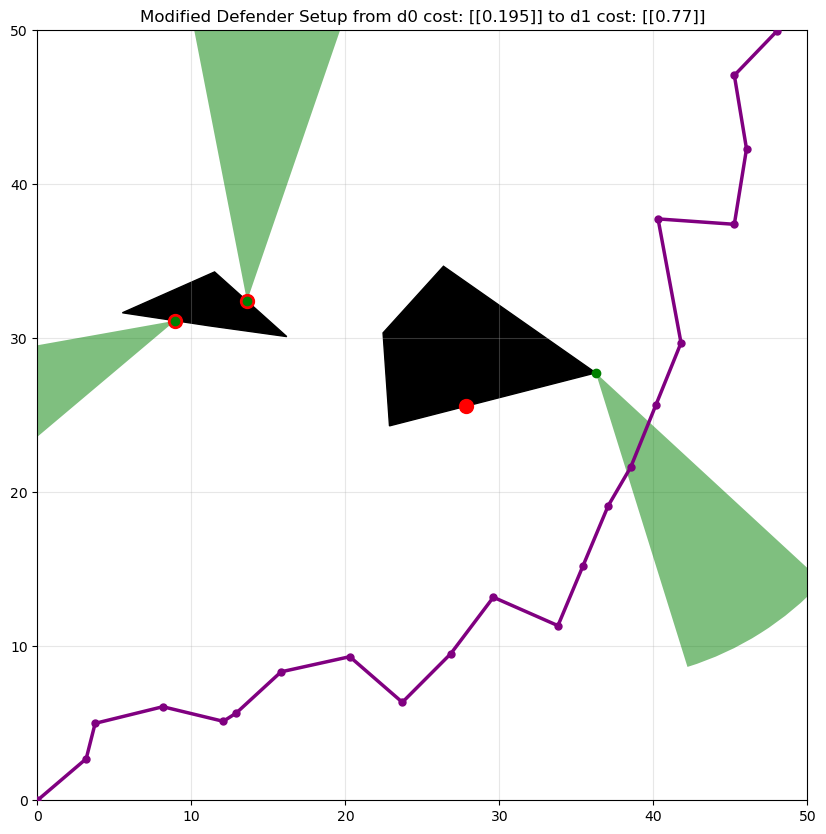

In [12]:
fig, ax = visualization(map_in=map_in, cam_dict=cam_dict, t=100,
    Va=stp_rrtstar_Va, Vb=stp_rrtstar_Vb, Ea=stp_rrtstar_Ea, Eb=stp_rrtstar_Eb,
    path_stp_rrt=stp_rrtstar_path,
    cam_x=cam_x, cam_y=cam_y,
    building_edge_vec=np.asarray(building_edge_vec),
    building_vector_vec=np.asarray(building_vector_vec),
    alpha_vec_mod=np.asarray(alpha_vec_mod),
    save_path="image/stp_rrtstar/stp_rrtstar_traj_updated_d1_good.png"
)

In [13]:
from matplotlib.animation import FuncAnimation

# ---------- helpers ----------
def _interp_path_at_time(path_xyz_t, t_query):
    P = np.asarray(path_xyz_t, dtype=float); assert P.shape[1] == 3
    t = P[:,2]; x = P[:,0]; y = P[:,1]
    if np.any(np.diff(t) < 0):
        idx = np.argsort(t); t, x, y = t[idx], x[idx], y[idx]
    tq = np.atleast_1d(t_query).astype(float)
    tq = np.clip(tq, float(t[0]), float(t[-1]))
    xq = np.interp(tq, t, x); yq = np.interp(tq, t, y)
    return (float(xq), float(yq)) if np.ndim(t_query) == 0 else (xq, yq)

def _assemble_sensor_centers(building_edge_vec, building_vector_vec, alpha_vec_mod):
    m = len(alpha_vec_mod)  # <-- add this line; no external m needed
    P0 = np.asarray(building_edge_vec,  dtype=float).reshape(m, 2)
    V  = np.asarray(building_vector_vec, dtype=float).reshape(m, 2)
    a  = np.asarray(alpha_vec_mod,      dtype=float).reshape(m, )
    S  = P0 + a[:,None]*V
    return S[:,0], S[:,1]

# ---------- main: dual-constellation animation ----------
def animate_scenario(map_in, cam_dict,
                          Va, Vb, Ea, Eb,
                          path_stp_rrt,
                          building_edge_vec, building_vector_vec, alpha_vec_mod,
                          t_scale=1.0, fps=30, trail_len_sec=2.0,
                          figsize=(10,10), dpi=120,
                          save_path_video=None,
                          edge_alpha=0.25, sensor_alpha=0.5,
                          orig_cam_x=None, orig_cam_y=None):
    """
    Draws BOTH sensor constellations:
      - Original cam_dict positions (green)
      - New positions from P0 + alpha * v (red)
    Both share identical sensor parameters (init_angle, bounds, panspeed, FOV)
    and rotate synchronously via your _bounce_angle().
    Drone follows path_stp_rrt with time-based interpolation.
    """
    st = map_in["st"]
    xmin, xmax, ymin, ymax = map(float, st["size"])

    # Positions: original (green)  <-- use explicit originals if given
    if orig_cam_x is not None and orig_cam_y is not None:
        cx0 = np.asarray(orig_cam_x, dtype=float).reshape(-1)
        cy0 = np.asarray(orig_cam_y, dtype=float).reshape(-1)
        m   = len(cx0)  # keep m consistent with originals
        # also slice spec arrays later with [:m] if needed
    else:
        m   = int(cam_dict["n"])
        cx0 = np.array(cam_dict["x"], dtype=float).reshape(m,)
        cy0 = np.array(cam_dict["y"], dtype=float).reshape(m,)

    # Positions: new (red)
    cx1, cy1 = _assemble_sensor_centers(building_edge_vec, building_vector_vec, alpha_vec_mod)
    # Keep lengths aligned
    m_eff = min(m, len(cx1))
    cx0, cy0, cx1, cy1 = cx0[:m_eff], cy0[:m_eff], cx1[:m_eff], cy1[:m_eff]

    # Spec (slice to m_eff to avoid mismatch if needed)
    spec = cam_dict["spec"]
    init_angles = np.array(spec["init_angle"], dtype=float).reshape(-1)[:m_eff]
    bound_arr   = np.array(spec["bound"], dtype=float).reshape(-1,2)[:m_eff]
    panspeeds   = np.array(spec["panspeed"], dtype=float).reshape(-1)[:m_eff]
    fov_half    = float(spec["fov"][0]); fov_range = float(spec["fov"][1])
    m = m_eff
    
    # Path timing
    P = np.asarray(path_stp_rrt, dtype=float); assert P.shape[1] == 3
    t0, tf = float(P[0,2]), float(P[-1,2])
    if not (tf > t0): raise ValueError("path_stp_rrt time column must be strictly increasing.")
    frame_dt = 1.0 / fps
    n_frames = int(np.ceil((tf - t0) / t_scale * fps)) + 1

    # Figure & static background
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    for i in range(st["n"]):
        poly = np.array(st[str(i)], dtype=float)
        ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))

    ax.plot(P[:,0], P[:,1], color='purple', lw=1.5, alpha=0.25, label='Planned Path')

    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", "box"); ax.grid(True, alpha=0.3)

    # Artists: centers + wedges for BOTH sets
    scatter_green = ax.scatter(cx0, cy0, s=36, c="green", marker="o", zorder=5, label="Sensors (original)")
    scatter_red   = ax.scatter(cx1, cy1, s=36, c="red",   marker="o", zorder=5, label="Sensors (new)")

    wedges_green, wedges_red = [], []
    # initialize wedges at t0; they’ll rotate together
    for i in range(m):
        theta0 = _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t0)
        ddeg   = np.degrees(fov_half)
        thdeg  = np.degrees(theta0)
        wg = Wedge(center=(cx0[i], cy0[i]), r=fov_range,
                   theta1=thdeg - ddeg, theta2=thdeg + ddeg,
                   facecolor="green", alpha=sensor_alpha, zorder=4)
        wr = Wedge(center=(cx1[i], cy1[i]), r=fov_range,
                   theta1=thdeg - ddeg, theta2=thdeg + ddeg,
                   facecolor="red",   alpha=sensor_alpha, zorder=4)
        ax.add_patch(wg); ax.add_patch(wr)
        wedges_green.append(wg); wedges_red.append(wr)

    # Drone marker and trail
    drone_point, = ax.plot([], [], 'o', color='magenta', ms=6, zorder=6)
    trail_line,  = ax.plot([], [], '-', color='magenta', lw=2, alpha=0.8, zorder=6)

    def _facing_angles(t_scene):
        th = np.empty(m, dtype=float)
        for i in range(m):
            th[i] = _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t_scene)
        return th

    def init():
        drone_point.set_data([], []); trail_line.set_data([], [])
        return [drone_point, trail_line, scatter_green, scatter_red, *wedges_green, *wedges_red]

    def update(frame):
        t_play  = frame * frame_dt
        t_scene = min(t0 + t_scale * t_play, tf)

        # shared headings for both sets
        th = _facing_angles(t_scene)
        ddeg = np.degrees(fov_half)
        for i in range(m):
            thdeg = np.degrees(th[i])
            wg = wedges_green[i]
            wg.set_center((cx0[i], cy0[i]))
            wg.set_theta1(thdeg - ddeg); wg.set_theta2(thdeg + ddeg)

            wr = wedges_red[i]
            wr.set_center((cx1[i], cy1[i]))
            wr.set_theta1(thdeg - ddeg); wr.set_theta2(thdeg + ddeg)

        # drone
        xd, yd = _interp_path_at_time(P, t_scene)
        drone_point.set_data([xd], [yd])

        # trail
        t_start = max(t0, t_scene - trail_len_sec)
        n_pts = max(2, int(fps * min(trail_len_sec, t_scene - t0) / 3))
        ts = np.linspace(t_start, t_scene, n_pts)
        xt, yt = _interp_path_at_time(P, ts)
        trail_line.set_data(xt, yt)

        return [drone_point, trail_line, scatter_green, scatter_red, *wedges_green, *wedges_red]

    ani = FuncAnimation(fig, update, frames=n_frames, init_func=init,
                        blit=True, interval=1000/fps, repeat=False)

    if save_path_video:
        os.makedirs(os.path.dirname(save_path_video), exist_ok=True)
        ext = os.path.splitext(save_path_video)[1].lower()
        if ext == ".gif":
            ani.save(save_path_video, writer="pillow", fps=fps)
        else:
            ani.save(save_path_video, writer="ffmpeg", fps=fps, dpi=dpi)
        print(f"Animation saved to: {save_path_video}")

    return fig, ani


In [14]:
# Optionally move sensors along edges once (keeps same FOV/bounds/angles/panspeed):
cx, cy = _assemble_sensor_centers(building_edge_vec=building_edge_vec,
                                  building_vector_vec=building_vector_vec,
                                  alpha_vec_mod=alpha_vec_mod)
cam_dict_moved = dict(cam_dict)
cam_dict_moved["x"] = cx.tolist()
cam_dict_moved["y"] = cy.tolist()

# Animate
# fig, ani = animate_scenario(
#     map_in, cam_dict_moved,
#     Va=stp_rrtstar_Va, Vb=stp_rrtstar_Vb, Ea=stp_rrtstar_Ea, Eb=stp_rrtstar_Ea,
#     path_stp_rrt=stp_rrtstar_path,   # (N,3): [x,y,t]
#     building_edge_vec=building_edge_vec,
#     building_vector_vec=building_vector_vec,
#     alpha_vec_mod=alpha_vec_mod,
#     t_scale=2.0, fps=60, trail_len_sec=2.0,
#     figsize=(10,10), dpi=120,
#     save_path_video="image/stp_rrtstar/demo.mp4",
#     edge_alpha=0.25, sensor_alpha=0.5,
#     orig_cam_x=cam_x, orig_cam_y=cam_y
# )


In [ ]:
# TODO
# Add casadi function so that we would slide around Pj(j) to find maximum cost given a_fixed

def optimize_camera_on_edge(edge_xy, cam_index, A_mat, cam_dict, P_fun,
                            outward_epsilon=1e-9, ipopt_opts=None):
    """
    Slide camera `cam_index` along a given edge to maximize P_fun(A,S).

    Inputs
    ------
    edge_xy     : tuple of endpoints ((x1,y1), (x2,y2)) for the mounting edge
    cam_index   : int, which camera in cam_dict to move
    A_mat       : casadi.DM or MX, shape (3, N)  -- attacker trajectory (x,y,t)
    cam_dict    : dict with fields:
                  'n' (#cameras), 'x' (np.array[m]), 'y' (np.array[m])
    P_fun       : casadi.Function with signature (A,S) -> (cost, dJdA, dJdS)
                  where S has shape (2, m) with rows [x; y]
    outward_epsilon : small nudge to keep position numerically on-edge but "outside" the wall if needed
    ipopt_opts      : optional dict to pass into IPOPT

    Returns
    -------
    result : dict with keys
        'alpha_opt'  : float in [0,1]
        'pos_opt'    : (x*, y*)
        'J_opt'      : float, maximal detection measure
        'sol_stats'  : solver stats
    """
    # --- Edge parameterization: E(alpha) = p0 + alpha*(p1 - p0), alpha in [0,1]
    (x1, y1), (x2, y2) = (tuple(edge_xy[0]), tuple(edge_xy[1]))
    p0 = np.array([float(x1), float(y1)], dtype=float)
    v  = np.array([float(x2 - x1), float(y2 - y1)], dtype=float)

    m = int(cam_dict['n'])
    x_fixed = np.asarray(cam_dict['x'], dtype=float).copy()
    y_fixed = np.asarray(cam_dict['y'], dtype=float).copy()
    assert 0 <= cam_index < m, "cam_index out of range"

    # --- Build Opti
    opti = ca.Opti()
    alpha = opti.variable()  # scalar in [0,1]
    opti.subject_to(alpha >= 0.0)
    opti.subject_to(alpha <= 1.0)

    # Position of the optimized camera along the edge
    x_alpha = p0[0] + alpha * v[0]
    y_alpha = p0[1] + alpha * v[1]

    # (Optional) microscopic outward nudge to avoid 'inside wall' numerical issues
    # (If you have a known outward normal, you can replace this with a directed offset.)
    x_alpha_nudged = x_alpha
    y_alpha_nudged = y_alpha + 0.0*outward_epsilon  # no-op by default

    # Assemble S (2 x m): all cameras fixed except cam_index
    S_sym = ca.MX.zeros(2, m)
    for j in range(m):
        if j == cam_index:
            S_sym[0, j] = x_alpha_nudged
            S_sym[1, j] = y_alpha_nudged
        else:
            S_sym[0, j] = float(x_fixed[j])
            S_sym[1, j] = float(y_fixed[j])

    # Evaluate detection measure via your provided function
    # P_fun returns (J, dJdA, dJdS); we want to MAXIMIZE J => minimize -J
    P_out = P_fun(A=A_mat, S=S_sym)
    # If P_fun has named outputs:
    if isinstance(P_out, dict):
        J = P_out.get('cost', list(P_out.values())[0])
    else:
        # tuple/list style
        J = P_out[0]

    opti.minimize(-J)

    # Solver
    if ipopt_opts is None:
        ipopt_opts = {"ipopt.print_level": 0, "print_time": 0, "ipopt.max_iter": 500}
    if ipopt_opts is None:
        ipopt_opts = {
            "print_time": False,        # CasADi option
            "ipopt.print_level": 0,     # IPOPT options use "ipopt." prefix
            "ipopt.max_iter": 500,
            "ipopt.tol": 1e-6,
        }
    opti.solver("ipopt", ipopt_opts)     # <-- only one dict


    # Initial guess: keep current camera position projected onto the edge
    # (helps IPOPT start somewhere sensible if you already have x/y)
    x0_c = float(x_fixed[cam_index])
    y0_c = float(y_fixed[cam_index])
    # Project current point onto edge to form alpha0
    denom = float(v[0]**2 + v[1]**2) if (v[0]**2 + v[1]**2) > 0 else 1.0
    alpha0 = ((x0_c - p0[0]) * v[0] + (y0_c - p0[1]) * v[1]) / denom
    alpha0 = float(np.clip(alpha0, 0.0, 1.0))
    opti.set_initial(alpha, alpha0)

    sol = opti.solve()
    alpha_opt = float(sol.value(alpha))
    x_opt = float(p0[0] + alpha_opt * v[0])
    y_opt = float(p0[1] + alpha_opt * v[1])

    # Get maximal detection value
    # Recompute J at optimum (or fetch from lam_g if desired)
    # Build S_mat at optimum for this evaluation:
    S_opt = np.vstack([x_fixed, y_fixed]).astype(float)
    S_opt[0, cam_index] = x_opt
    S_opt[1, cam_index] = y_opt
    P_out_opt = P_fun(A=A_mat, S=ca.DM(S_opt))
    J_opt = float(P_out_opt['cost'] if isinstance(P_out_opt, dict) else P_out_opt[0])


    return {
        "alpha_opt": alpha_opt,
        "pos_opt": (x_opt, y_opt),
        "J_opt": J_opt,
        "sol_stats": sol.stats()
    }


In [37]:
P_fun = build_casadi_P(n=len(stp_rrtstar_path), m = map_in['ncam'], beta=0.3)
A_mat = ca.DM(np.vstack([np.array(stp_rrtstar_path)[:,0], np.array(stp_rrtstar_path)[:,1], np.array(stp_rrtstar_path)[:,2]]))
S_mat = ca.DM(np.vstack([cam_dict['x'], cam_dict['y']]))

# Optimal Camera Positions for maximized PoD
optimal_placement = {}
optimal_placement['alpha_opt'] = []
optimal_placement['pos_opt'] = []
optimal_placement['J_opt'] = []

# Iteration
for cam_index in range(num_sensors):
    print(cam_index)
    E0 = np.asarray(building_edge_vec[cam_index], dtype=float)          # edge start (x,y)
    v  = np.asarray(building_vector_vec[cam_index], dtype=float)        # edge vector (Δx,Δy)
    E1 = E0 + v                                                 # edge end (x,y)
    edge_xy = (tuple(E0), tuple(E1))                            # as required by the function

    result = optimize_camera_on_edge(edge_xy, cam_index, A_mat, cam_dict, P_fun,
                                outward_epsilon=1e-9, ipopt_opts=None)

    print('==================================')
    print('Original α =', alpha_vec[cam_index])
    print("α* =", result["alpha_opt"])
    print("x*, y* =", result["pos_opt"])
    print("Max detection J* =", result["J_opt"])

    optimal_placement['alpha_opt'].append(result['alpha_opt'])
    optimal_placement['pos_opt'].append(result['pos_opt'])
    optimal_placement['J_opt'].append(result['J_opt'])


0
Original α = 1
α* = 1.0000000084782625
x*, y* = (36.25649045831198, 27.753354521561246)
Max detection J* = 0.7704299011686039
1
Original α = 0.6055995301393268
α* = 0.9999994711421651
x*, y* = (11.171621119194086, 30.805282666293802)
Max detection J* = 0.19641436132917156
2
Original α = 0.5507846417600734
α* = 1.1168034574516737e-07
x*, y* = (16.18943613926142, 30.10850379196296)
Max detection J* = 0.2019161007154897


Figure saved to: image/stp_rrtstar/stp_rrtstar_traj_optimal.png


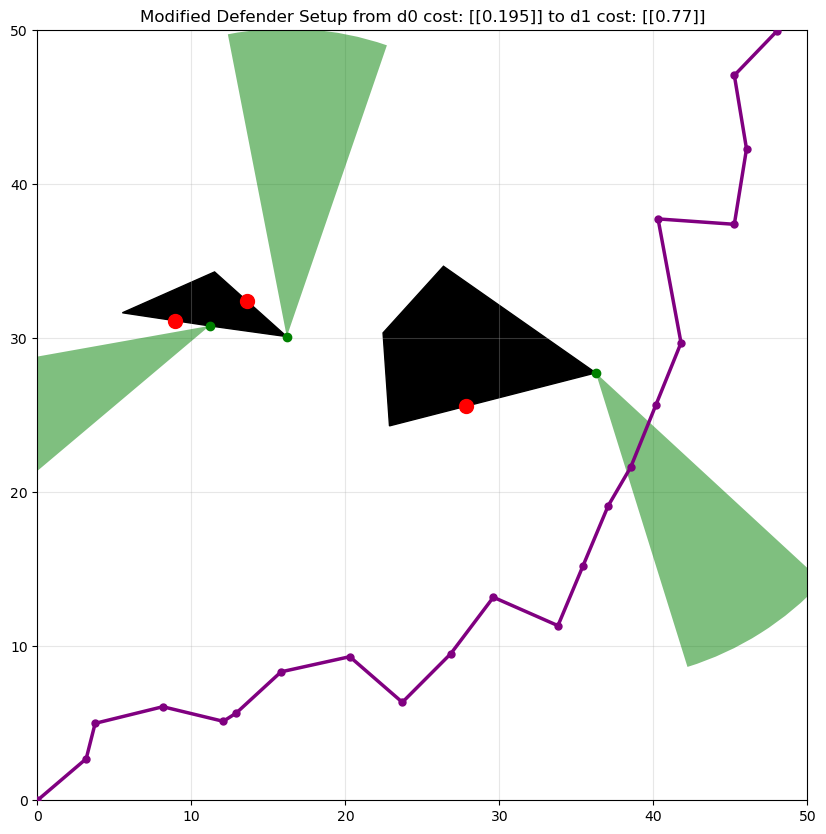

In [38]:
fig, ax = visualization(map_in=map_in, cam_dict=cam_dict, t=100,
    Va=stp_rrtstar_Va, Vb=stp_rrtstar_Vb, Ea=stp_rrtstar_Ea, Eb=stp_rrtstar_Eb,
    path_stp_rrt=stp_rrtstar_path,
    cam_x=cam_x, cam_y=cam_y,
    building_edge_vec=np.asarray(building_edge_vec),
    building_vector_vec=np.asarray(building_vector_vec),
    alpha_vec_mod=np.asarray(optimal_placement['alpha_opt']),
    save_path="image/stp_rrtstar/stp_rrtstar_traj_optimal.png"
)